# Validation lab — does the dependence estimator measure what it claims?

Three checks on the `R[j,k]` matrix from `mixture_lab`, before it carries any weight in the
thesis. None of them touches the drift engine.

| § | check | question | pass looks like |
|---|---|---|---|
| 2 | **excitation space** | is `E` invariant to the size of the drift? | slope ≈ 1 vs beta, in at least one space |
| 3 | **placebo** | does the estimator report dependence when nothing drifted? | real ≫ placebo, both on and off diagonal |
| 4 | **superposition** | does the single-district design compose? | `pooled_slope → 1` as beta falls |

**Why §2 exists.** On Graeme, pressure's shape-space slope tracked the volume level factor
`9.19^β` almost exactly (0.422 / 0.613 / 0.785 / 1.000 / 1.126 / 1.418 against a predicted
0.46 / 0.64 / 0.81 / 1.00 / 1.12 / 1.36). Dividing by the *shape* norm was not removing the
excitation, because pressure responds to volume. Native space (mca, L/s) divides by the
district's demand change in L/s instead, which carries level and shape together.

**Expect the two spaces to split by question, not by quality.** Native is the linearised
operator and is the right form for "is this invariant". Shape is z-scored per phase, which
removes the network-wide level shift every gauge shares — so it is the right form for
*attribution*, and the one the FL scaler leaves behind. §2 reports both and lets the numbers
assign them.

## 0. Setup

In [1]:
%matplotlib inline
import sys, warnings, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220, "display.max_columns", 80, "display.max_rows", 200)

HERE = pathlib.Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "conf" / "base").exists())
for p in (HERE, ROOT / "src", ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import landuse_world as lw, signal_probe as sp, landuse_sweep as ls
import mixture_probe as mp, validation_probe as vp

SWEEP = ROOT / "data" / "09_experiments" / "landuse_sweep"
VAL = ROOT / "data" / "09_experiments" / "validation"
VAL.mkdir(parents=True, exist_ok=True)
print(SWEEP.exists(), VAL)

True c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\validation


## 1. Configuration

In [2]:
CFG = ls.SweepCfg(
    networks=("ky7", "dtown", "graeme"),
    betas=(0.0, 0.15, 0.25, 0.35, 0.40, 0.50),
    districts=None, to_land_use="industrial", to_income="low",
    n_months=44, days_per_month=14, warmup_months=2,
    max_neighbors_per_month=8, growth_chance=1.0,
    drift_ramp_days=7, seasonality_scale=0.0)

NETWORK, BETA = "graeme", 0.35
NULL_FACTOR, CORE_PURITY = 1.5, 0.85
INTENSITY_RATIO = 9.19          # low-income residential -> industrial

# Cache sanity check FIRST. A world directory is content-addressed by
# sim_hash(asdict(cfg)), so any change to WorldCfg's fields renames every
# world and the cache silently vanishes. If this reports 0, the configs here
# do not match the ones the sweep ran -- compare the two CFG blocks rather
# than re-solving 30 worlds.
probe_cfg = CFG.base(NETWORK)
import dataclasses
names = ls.district_names(ROOT, NETWORK)
allres = "_".join(["LR"] * len(names))
found = sum((SWEEP / lw.sim_hash(dataclasses.replace(
    probe_cfg, map_code=allres, tgt_district=d, beta=b)) / "manifest.json").exists()
    for d in names for b in CFG.betas)
print(f"cache: {found}/{len(names) * len(CFG.betas)} worlds found in {SWEEP.name}")
if not found:
    raise SystemExit("no cached worlds match this CFG — check it against the "
                     "sweep notebook's CFG before running anything else")

BASES = {}
for b in CFG.betas:
    pr = mp.load_cells(NETWORK, b, CFG, ROOT, SWEEP)
    if not pr:
        continue
    try:
        if not mp.horizon_check(pr)["ok"].all():
            print(f"beta={b}: horizon too short, skipped"); continue
        BASES[b] = mp.build_mixture(pr, null_factor=NULL_FACTOR,
                                    core_purity=CORE_PURITY, verbose=False)
        print(f"beta={b}: {len(pr)} worlds ok")
    except Exception as exc:
        print(f"beta={b}: {type(exc).__name__}: {str(exc)[:110]}")

if BETA not in BASES:
    raise SystemExit(f"reference beta {BETA} unusable; pick one of {sorted(BASES)}")
RES = BASES[BETA]
PROBES = mp.load_cells(NETWORK, BETA, CFG, ROOT, SWEEP)
print("\nusable betas:", sorted(BASES), "| reference:", BETA)

cache: 30/30 worlds found in landuse_sweep


beta=0.0: 5 worlds ok
beta=0.15: 5 worlds ok
beta=0.25: 5 worlds ok
beta=0.35: 5 worlds ok
beta=0.4: 5 worlds ok
beta=0.5: 5 worlds ok

usable betas: [0.0, 0.15, 0.25, 0.35, 0.4, 0.5] | reference: 0.35


## 2. Excitation space

`E` is defined as response *per unit of excitation*, so a linear network gives a
beta-invariant `E`: slope 1 against any reference beta. The dashed line is what a purely
volume-driven response would give — if the observed slope lies on it, the normalisation has
not removed the excitation at all.

,space,kind,beta,n,r,slope,predicted_if_volume,slope_err_vs_1,slope_err_vs_volume
0,shape,flow,0.00,652,0.820,0.740,0.460,0.260,0.280
1,shape,flow,0.15,650,0.880,0.827,0.642,0.173,0.185
2,shape,flow,0.25,649,0.918,0.885,0.801,0.115,0.084
3,shape,flow,0.40,649,0.942,0.998,1.117,0.002,0.119
4,shape,flow,0.50,664,0.848,0.999,1.395,0.001,0.396
5,native,flow,0.00,725,0.982,0.983,0.460,0.017,0.523
6,native,flow,0.15,760,0.990,0.999,0.642,0.001,0.357
7,native,flow,0.25,708,0.992,0.999,0.801,0.001,0.198
8,native,flow,0.40,693,0.997,0.995,1.117,0.005,0.122
9,native,flow,0.50,695,0.993,0.987,1.395,0.013,0.408


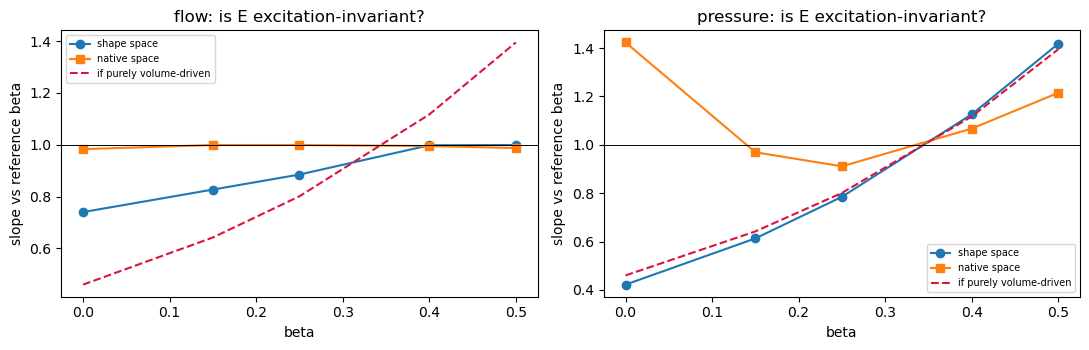

mean |slope - 1| by space and kind:
kind      space 
flow      native    0.007
          shape     0.110
pressure  native    0.165
          shape     0.345

mean |slope - volume prediction|:
kind      space 
flow      native    0.322
          shape     0.213
pressure  native    0.326
          shape     0.023


In [3]:
LR = vp.level_ratios(sorted(BASES), BETA, INTENSITY_RATIO)
EXC = pd.concat([vp.excitation_report(BASES, BETA, k, LR)
                 for k in ("flow", "pressure")], ignore_index=True)
display(EXC)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, k in zip(axes, ("flow", "pressure")):
    vp.plot_excitation(EXC, k, ax=ax)
plt.tight_layout(); plt.show()

print("mean |slope - 1| by space and kind:")
print(EXC.groupby(["kind", "space"])["slope_err_vs_1"].mean().round(3).to_string())
print("\nmean |slope - volume prediction|:")
print(EXC.groupby(["kind", "space"])["slope_err_vs_volume"].mean().round(3).to_string())

In [4]:
# The other half of the space question: which space ATTRIBUTES. Native deltas carry the
# network-wide level shift that every gauge shares, so projections onto different districts'
# directions are collinear; z-scoring removes it. `diag_dominance` is the test — share of
# gauges whose largest |E| is their own district, with no threshold and no tiering.
display(pd.concat([mp.estimator_checks(RES, k, space=sp_)
                   for k in ("flow", "pressure")
                   for sp_ in ("shape", "native")], ignore_index=True))

for sp_ in ("shape", "native"):
    D_, R_, _ = mp.dependence(RES, "flow", space=sp_)
    A = R_.to_numpy().copy(); np.fill_diagonal(A, np.nan)
    print(f"{sp_:7s} flow  off-diag mean {np.nanmean(A):.3f}  max {np.nanmax(A):.3f}")

,kind,space,n_gauges,noise_pass_rate,shrink_effect_r,diag_dominance,median_nu_over_proj
0,flow,shape,164,0.2122,0.9994,0.6524,0.1121
1,flow,native,164,0.1598,1.0000,0.6890,0.0502
2,pressure,shape,112,0.0000,1.0000,0.2589,0.0033
3,pressure,native,112,0.0000,1.0000,0.5268,0.0018


shape   flow  off-diag mean 0.398  max 2.293
native  flow  off-diag mean 0.332  max 1.392


## 3. Placebo

Same estimator, same real excitation directions `u_k`, but the sensor delta comes from the
first half of the **settled** window against the second — a stretch `settled_window` already
certified as stationary. The noise floor comes from two quarters of the first half, so it is
independent of the delta it gates; using the same split for both would make the soft threshold
return exactly zero and the test vacuous.

Every entry should be ≈ 0, **diagonal included**. `diag_ratio` is the real diagonal over the
placebo diagonal — the signal-to-pipeline-artefact ratio, and the number that licenses the
method. `off_ratio` is the same for the coupling: if the real off-diagonal is not clearly
above its placebo, the coupling being reported is not real.

`placebo_survivors` near 0.5 is expected and not a failure — soft-thresholding shrinks rather
than zeroes, so about half of pure-noise cells keep a small residual. The criterion is the
magnitude ratio, not the count.

In [5]:
PLAC = vp.build_placebo(PROBES)
REPS = {}
rows = []
for kind in ("flow", "pressure"):
    for space in ("shape", "native"):
        r = vp.placebo_report(RES, PLAC, kind, space)
        REPS[(kind, space)] = r
        rows.append(r["stats"])
PLAC_STATS = pd.concat(rows, ignore_index=True)
display(PLAC_STATS)

  placebo District_A: settled halves 7..44 months
  placebo District_B: settled halves 9..44 months
  placebo District_C: settled halves 9..44 months
  placebo District_D: settled halves 10..44 months
  placebo District_E: settled halves 9..44 months


,kind,space,real_diag,placebo_diag,real_off,placebo_off,placebo_survivors,real_survivors,diag_ratio,off_ratio,verdict
0,flow,shape,0.6664,0.0007,0.1636,0.0026,0.4817,0.7878,1012.2983,62.0385,pass
1,flow,native,0.1466,0.0002,0.0491,0.0002,0.5329,0.8402,628.0595,282.4059,pass
2,pressure,shape,0.1379,0.0004,0.1201,0.0004,1.0000,1.0000,337.8182,322.6226,pass
3,pressure,native,0.0203,0.0000,0.0179,0.0000,0.4000,1.0000,699.0838,768.8484,pass


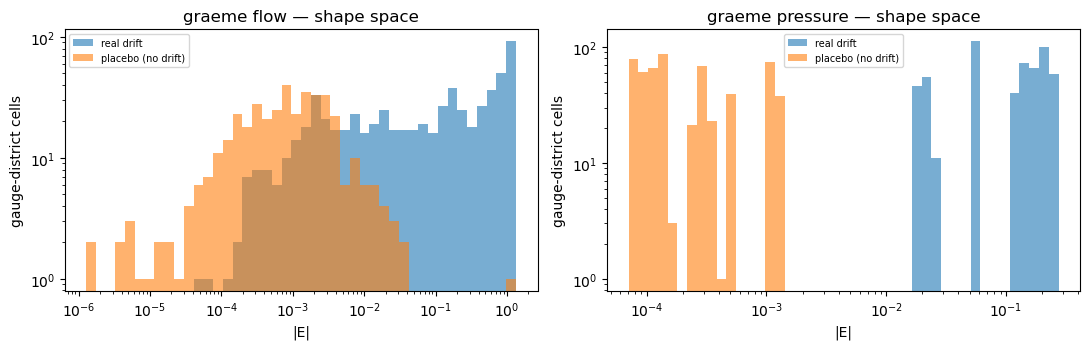

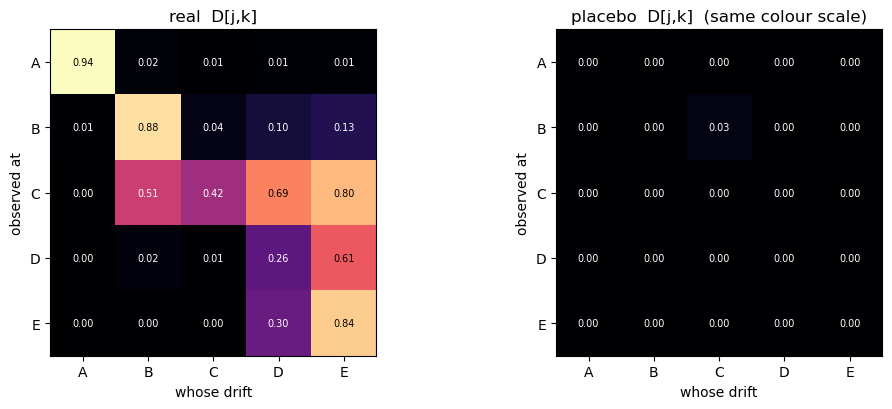

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, kind in zip(axes, ("flow", "pressure")):
    vp.plot_placebo(REPS[(kind, "shape")], ax=ax, title=f"{NETWORK} {kind} — shape space")
plt.tight_layout(); plt.show()

# The placebo matrix itself, next to the real one.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
mp.plot_matrix(REPS[("flow", "shape")]["D_real"], ax=axes[0],
               title="real  D[j,k]", xlabel="whose drift", ylabel="observed at")
mp.plot_matrix(REPS[("flow", "shape")]["D_placebo"], ax=axes[1],
               title="placebo  D[j,k]  (same colour scale)",
               vmax=float(np.nanmax(REPS[("flow", "shape")]["D_real"].to_numpy())),
               xlabel="whose drift", ylabel="observed at")
plt.tight_layout(); plt.show()

## 4. Superposition

One world where two districts drift together. The test is at vector level, which needs no
projection: for every gauge, compare the weekly-profile change in the joint world against the
sum of the two single-district changes.

**Run it across beta, not once.** Any network saturates if the drift is large enough, so a
single "not additive" says nothing. The informative object is the trend: if `pooled_slope`
approaches 1 as beta falls, the non-additivity is a magnitude effect and the dependence matrix
is sound in the regime it is quoted for. A slope flat and far from 1 at every beta means the
single-district design does not compose, and that has to be stated rather than hidden.

`co_targets` is a new field on `WorldCfg`. It needs no engine change: `build_drift_schedule`
already carries `(to_income, to_land_use)` per row, and `evolve_assignments` and
`apply_drift_ramp` read them per row — so two schedules concatenated is a schema-compatible
extension. The pair below should be two districts the `R` matrix says are coupled, since an
uncoupled pair is additive trivially.

In [7]:
PAIR = ("District_D", "District_E")      # pick a coupled pair from R
BETAS_SUP = [b for b in (0.0, 0.15, 0.35) if b in BASES]
print("pair:", PAIR, "| betas:", BETAS_SUP)

SUP, SUPW = [], {}
for b in BETAS_SUP:
    import dataclasses
    names = ls.district_names(ROOT, NETWORK)
    allres = "_".join(["LR"] * len(names))
    cfg_a = dataclasses.replace(CFG.base(NETWORK), map_code=allres,
                                tgt_district=PAIR[0], beta=b)
    cfg_b = dataclasses.replace(cfg_a, tgt_district=PAIR[1])
    cfg_ab = vp.superposed_cfg(cfg_a, *PAIR)
    try:
        P_a = vp.load_or_build(cfg_a, ROOT, SWEEP)
        P_b = vp.load_or_build(cfg_b, ROOT, SWEEP)
        P_ab = vp.load_or_build(cfg_ab, ROOT, VAL)
    except Exception as exc:
        print(f"beta={b}: {type(exc).__name__}: {str(exc)[:120]}"); continue
    SUPW[b] = (P_a, P_b, P_ab)
    for space in ("native", "shape"):
        SUP.append(vp.superposition(P_a, P_b, P_ab, space=space,
                                    label=f"beta={b}")["summary"])
SUP = pd.concat(SUP, ignore_index=True) if SUP else pd.DataFrame()
display(SUP)

pair: ('District_D', 'District_E') | betas: [0.0, 0.15, 0.35]
  cache 6a63b5bc
  cache 1dafe9b2
  solving 66877acf ...
run_hydraulics: 1 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['110']).
  cache 13a3ff4e
  cache 646fa340
  solving 63e3f9de ...
run_hydraulics: 1 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['110']).
  cache 4c44c90a
  cache 3b889504
  solving 225fcb1f ...
run_hydraulics: 1 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['110']).


,label,kind,space,n,pooled_slope,pooled_r,median_slope,median_rel_err,p90_rel_err,share_within_10%,verdict
0,beta=0.0,flow,native,164,0.9994,0.9992,0.9761,0.0887,0.9947,0.6768,additive
1,beta=0.0,pressure,native,112,0.9568,0.9990,0.9584,0.0710,0.0789,1.0000,additive
2,beta=0.0,flow,shape,164,0.7939,0.8111,0.9139,0.6066,1.0000,0.0732,weakly additive
3,beta=0.0,pressure,shape,112,1.4037,0.9837,1.3969,0.3293,0.3507,0.0000,NOT additive
4,beta=0.15,flow,native,164,0.9872,0.9928,0.9807,0.0940,1.0000,0.6341,additive
5,beta=0.15,pressure,native,112,1.0613,0.9971,1.0596,0.1176,0.1263,1.0000,additive
6,beta=0.15,flow,shape,164,0.7642,0.8386,0.9631,0.4864,1.0000,0.1280,weakly additive
7,beta=0.15,pressure,shape,112,1.3558,0.9795,1.3492,0.3204,0.3422,0.0000,NOT additive
8,beta=0.35,flow,native,164,0.9876,0.9915,0.9841,0.0951,0.9814,0.6220,additive
9,beta=0.35,pressure,native,112,1.2036,0.9895,1.1997,0.1867,0.1964,0.0000,weakly additive


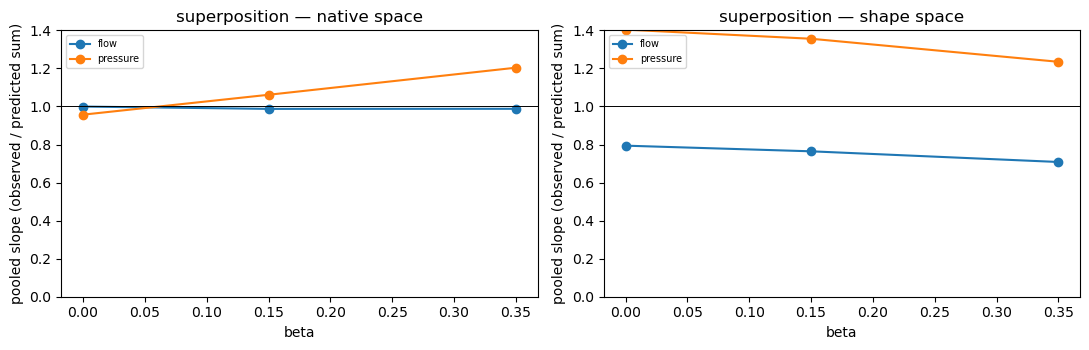

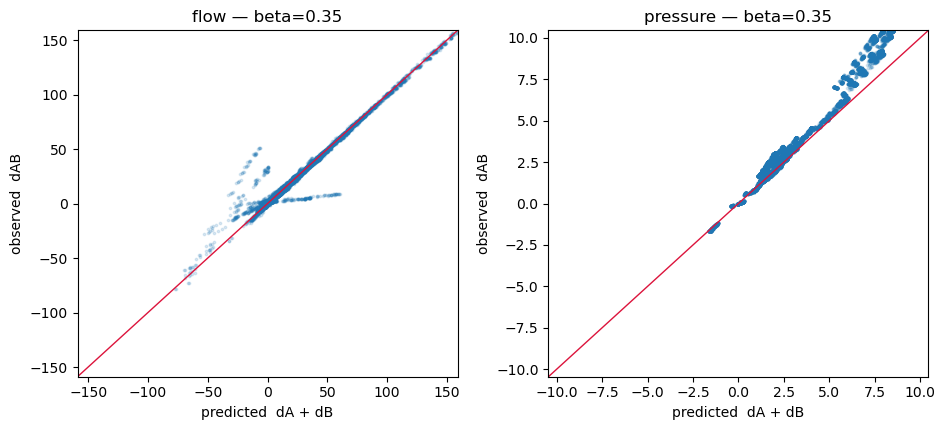

,id,kind,district,role,slope,rel_err,cos
14,q_184,flow,District_A,external,0.9995,0.0079,1.0000
61,q_104,flow,District_C,boundary,1.0074,0.0118,1.0000
112,q_94,flow,District_D,boundary,0.9952,0.0131,0.9999
114,q_97,flow,District_D,boundary,1.0061,0.0126,0.9999
25,q_136,flow,District_B,boundary,0.9897,0.0126,1.0000
77,q_129,flow,District_C,boundary,0.9906,0.0189,0.9999
113,q_96,flow,District_D,internal,1.0055,0.0109,1.0000
99,q_45,flow,District_D,internal,1.0098,0.0151,0.9999
106,q_69,flow,District_D,internal,0.9841,0.0196,0.9999
156,q_67,flow,District_E,boundary,0.9839,0.0196,0.9999


In [11]:
if len(SUP):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for ax, space in zip(axes, ("native", "shape")):
        d = SUP[SUP["space"] == space].copy()
        d["beta"] = d["label"].str.replace("beta=", "").astype(float)
        for kind, g in d.groupby("kind"):
            g = g.sort_values("beta")
            ax.plot(g["beta"], g["pooled_slope"], marker="o", label=kind)
        ax.axhline(1.0, color="k", lw=.7)
        ax.set(xlabel="beta", ylabel="pooled slope (observed / predicted sum)",
               title=f"superposition — {space} space", ylim=(0, 1.4))
        ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

    b0 = max(SUPW)
    res0 = vp.superposition(*SUPW[b0], space="native", label=f"beta={b0}")
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4))
    for ax, kind in zip(axes, ("flow", "pressure")):
        vp.plot_superposition(res0, kind, ax=ax)
        ax.set_title(f"{kind} — beta={b0}")
    plt.tight_layout(); plt.show()
    display(res0["per_gauge"].nlargest(10, "obs_norm")[
        ["id", "kind", "district", "role", "slope", "rel_err", "cos"]])

A gauge with `cos` near −1 is not a small deviation from additivity: its joint response points
the *opposite* way to the sum of the two single responses. On flow that means a link whose
direction reverses when both districts move — which is exactly the `foreign` tier from
`mixture_lab`, and a good place to check whether the two labels pick out the same elements.

In [9]:
if len(SUP):
    MIXF = RES["mixture"].set_index("id")
    pg = res0["per_gauge"].set_index("id")
    j = pg.join(MIXF[["tier", "purity", "second", "w_second"]], how="inner")
    display(j.groupby("tier")[["slope", "rel_err", "cos"]].median().round(3))
    display(j[j["cos"] < -0.5].nlargest(10, "obs_norm")[
        ["kind", "district", "tier", "purity", "second", "slope", "cos"]])

,slope,rel_err,cos
tier,,,
core,0.695,0.528,0.995
foreign,0.960,0.070,0.998
transition,0.962,0.076,0.998
unusable,0.824,0.310,0.973


,kind,district,tier,purity,second,slope,cos
id,,,,,,,
q_110,flow,District_C,transition,0.251419,District_E,-1.0217,-0.7789


## 5. Verdict

In [10]:
flow_ratio = float(PLAC_STATS.query("kind=='flow' and space=='shape'")["diag_ratio"].iat[0])

V = pd.DataFrame([{
    "check": "excitation invariance",
    "flow": EXC[EXC["kind"] == "flow"].groupby("space")["slope_err_vs_1"].mean().idxmin(),
    "pressure": EXC[EXC["kind"] == "pressure"].groupby("space")["slope_err_vs_1"].mean().idxmin(),
    "detail": "space with the smaller mean |slope-1|",
}, {
    "check": "placebo",
    "flow": PLAC_STATS.query("kind=='flow' and space=='shape'")["verdict"].iat[0],
    "pressure": PLAC_STATS.query("kind=='pressure' and space=='shape'")["verdict"].iat[0],
    "detail": f"diag_ratio flow {flow_ratio:.0f}x",
}, {
    "check": "superposition",
    "flow": (SUP.query("kind=='flow' and space=='native'")
             .sort_values("label")["verdict"].iloc[0] if len(SUP) else "not run"),
    "pressure": (SUP.query("kind=='pressure' and space=='native'")
                 .sort_values("label")["verdict"].iloc[0] if len(SUP) else "not run"),
    "detail": "verdict at the SMALLEST beta run",
}])
display(V)

VAL.mkdir(parents=True, exist_ok=True)
EXC.to_csv(VAL / f"{NETWORK}_excitation.csv", index=False)
PLAC_STATS.to_csv(VAL / f"{NETWORK}_placebo.csv", index=False)
if len(SUP):
    SUP.to_csv(VAL / f"{NETWORK}_superposition.csv", index=False)
V.to_csv(VAL / f"{NETWORK}_verdict.csv", index=False)
print("written ->", VAL)

,check,flow,pressure,detail
0,excitation invariance,native,native,space with the smaller mean |slope-1|
1,placebo,pass,pass,diag_ratio flow 1012x
2,superposition,additive,additive,verdict at the SMALLEST beta run


written -> c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\validation


## 6. How to read it

**Excitation.** Whichever space has the smaller mean `|slope − 1|` is the one to quote for
invariance. If pressure's shape-space slope sits on the volume line while native's sits on 1,
that confirms the diagnosis and pressure's dependence should be quoted in native units.
Attribution stays in shape space regardless — check `diag_dominance` in §2 to see why.

**Placebo.** `pass` on both ratios is the licence for everything in `mixture_lab`. A high
`diag_ratio` with a low `off_ratio` is the dangerous case: the diagonal is real but the
coupling is at the noise level, so `R`'s off-diagonal entries should not be quoted as
measurements.

**Superposition.** Read the trend, not the verdict at one beta. Slope rising toward 1 as beta
falls means the matrix is valid in the small-signal limit and should be quoted with the beta it
was measured at. Flat and far from 1 means single-district excitation does not compose, and
the honest statement is that `R` describes one drift at a time.

**Then the partition round.** With the estimator validated, the prediction to state in advance
is that changing the district assignment moves `R` while leaving `noise_pass_rate`,
`shrink_effect_r`, `diag_dominance`, the core/transition purity gap and these three checks
where they are.